In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
import warnings
import random


# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# ==========================================
# 1. SIMULATION PARAMETERS
# ==========================================
N = 500   
p = 20    
theta_true = 0.5  
iterations = 200  

# Arrays to store the estimates from each approach
naive_estimates = []
overfit_estimates = []
dml_estimates = []


In [29]:
# ==========================================
# 2. Simulation Loop
# ==========================================


for i in range(iterations):
    
    np.random.seed(67)
    # --- A. Data Generating Process (DGP) ---
    # Generate covariates X
    X = np.random.normal(0, 1, (N, p))

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_nonlinear_full = poly.fit_transform(X)

    selected_indices = np.random.choice(X_nonlinear_full.shape[1], size=150, replace=False)
    X_nonlinear = X_nonlinear_full[:, selected_indices]

    num_combinations = X_nonlinear.shape[1] 
    weights = np.random.randn(num_combinations, 2)

    final_variable = X_nonlinear @ weights
    m_ofX = final_variable[:, 0]
    g_ofX = final_variable[:, 1]

    # Generate structural errors
    V = np.random.normal(0, 1, N)
    U = np.random.normal(0, 1, N)
    
    # Generate Treatment (D) and Outcome (Y)
    D = m_ofX + V
    Y = D * theta_true + g_ofX + U

    # --- B. Naive Estimator (No Orthogonalization) ---
    # We estimate g_0 by naively predicting Y from X directly
    rf_naive = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
    rf_naive.fit(X, Y)
    g_hat_naive = rf_naive.predict(X)
     
    theta_naive = np.mean(D * (Y - g_hat_naive)) / np.mean(D**2)
    naive_estimates.append(theta_naive)

    # --- C. Overfitted Orthogonal Estimator (No Cross-fitting) ---
    # Here we orthogonalize, but we train and predict on the FULL sample
    rf_m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
    rf_l = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
    rf_m.fit(X, D)
    rf_l.fit(X, Y)
    m_hat_full = rf_m.predict(X)
    l_hat_full = rf_l.predict(X)  
    V_hat_full = D - m_hat_full
    W_hat_full = Y - l_hat_full
    # Using Robinson's partialling out formula (Note 3, Page 4 of the paper)
    theta_overfit = np.mean(V_hat_full * W_hat_full) / np.mean(V_hat_full**2)
    overfit_estimates.append(theta_overfit)

    # --- D. DML Estimator (Orthogonalization + Cross-Fitting) ---
    kf = KFold(n_splits=5, shuffle=True, random_state=i)
    V_hat_cf = np.zeros(N)
    W_hat_cf = np.zeros(N)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        D_train, D_test = D[train_idx], D[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        
        # Train on Fold A, Predict on Fold B
        rf_m_cf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_m_cf.fit(X_train, D_train)
        V_hat_cf[test_idx] = D_test - rf_m_cf.predict(X_test)
        
        rf_l_cf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_l_cf.fit(X_train, Y_train)
        W_hat_cf[test_idx] = Y_test - rf_l_cf.predict(X_test)
    
    theta_dml = np.mean(V_hat_cf * W_hat_cf) / np.mean(V_hat_cf**2)
    dml_estimates.append(theta_dml)

print(f"Finished {iterations} iterations. Thank you for waiting!")


Finished 200 iterations. Thank you for waiting!


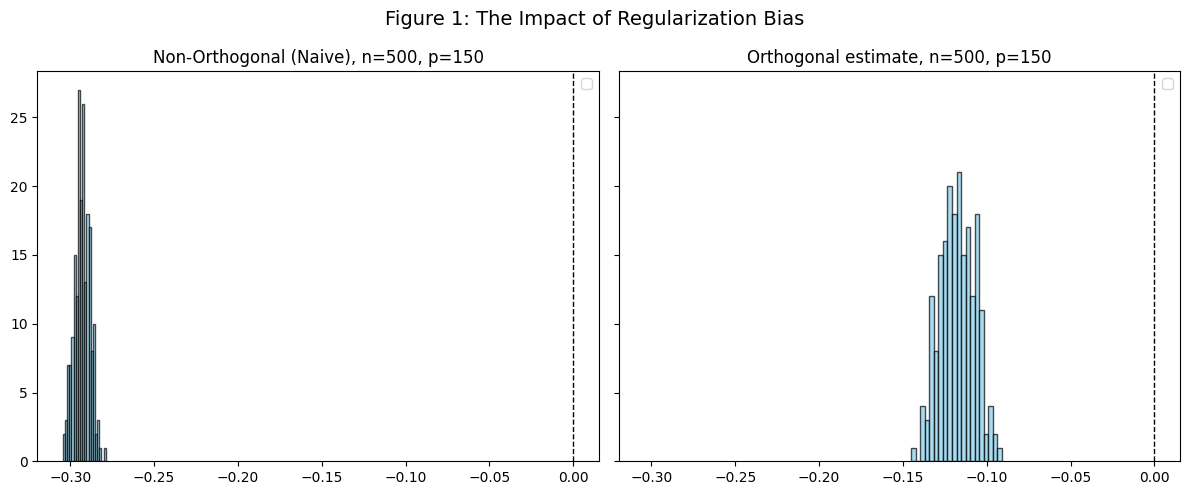

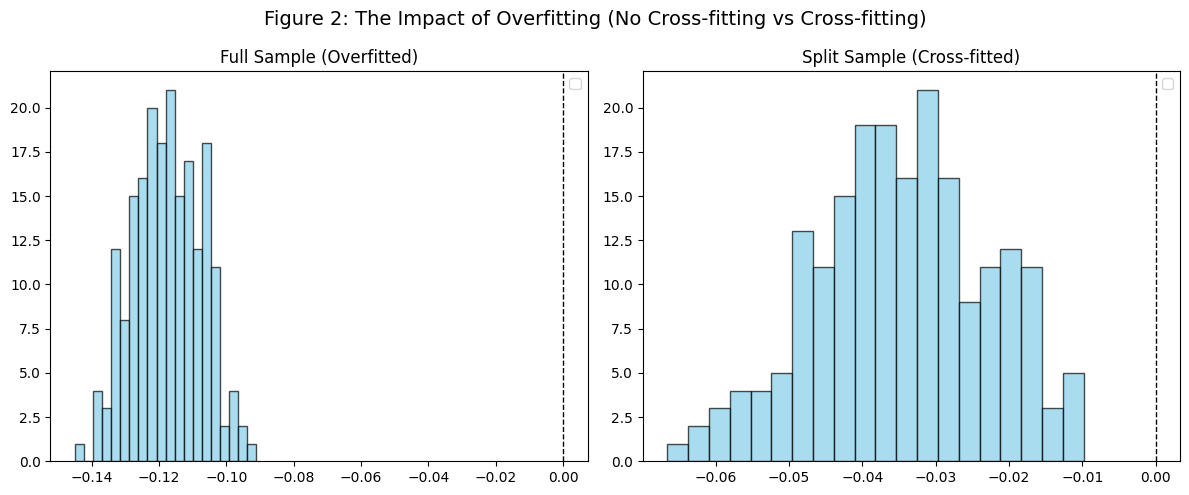

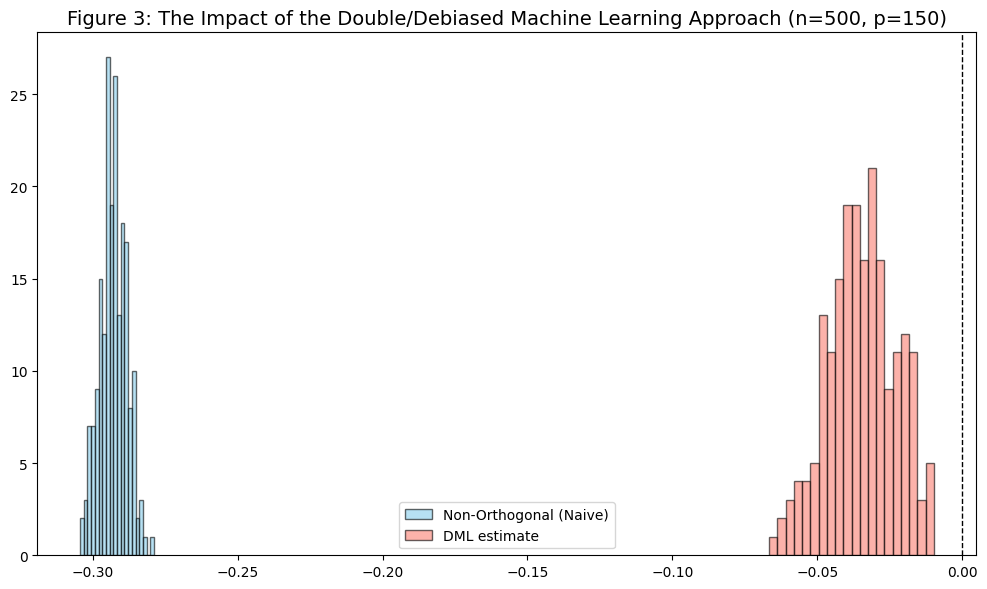

In [34]:
# ==========================================
# 3. PLOTTING THE RESULTS
# ==========================================
# Center the estimates around 0 for the histograms
centered_naive = np.array(naive_estimates) - theta_true
centered_overfit = np.array(overfit_estimates) - theta_true
centered_dml = np.array(dml_estimates) - theta_true


# --- Recreating Figure 1: Regularization Bias ---

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: Naive
ax1.hist(centered_naive, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
#plot_normal_curve(ax1, centered_dml) # Use DML std to show where it *should* be
ax1.axvline(0, color='black', linestyle='dashed', linewidth=1)
ax1.set_title("Non-Orthogonal (Naive), n=500, p=150")
ax1.legend()

# Right: DML
ax2.hist(centered_overfit, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
#plot_normal_curve(ax2, centered_dml)
ax2.axvline(0, color='black', linestyle='dashed', linewidth=1)
ax2.set_title("Orthogonal estimate, n=500, p=150")
ax2.legend()

fig1.suptitle("Figure 1: The Impact of Regularization Bias", fontsize=14)
plt.tight_layout()
plt.show()

# --- Recreating Figure 2: Overfitting Bias ---
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Overfitted (Full Sample)
ax3.hist(centered_overfit, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(0, color='black', linestyle='dashed', linewidth=1)
ax3.set_title("Full Sample (Overfitted)")
ax3.legend()

# Right: DML (Split Sample)
ax4.hist(centered_dml, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(0, color='black', linestyle='dashed', linewidth=1)
ax4.set_title("Split Sample (Cross-fitted)")
ax4.legend()

fig2.suptitle("Figure 2: The Impact of Overfitting (No Cross-fitting vs Cross-fitting)", fontsize=14)
plt.tight_layout()
plt.show()

# Create a single plot for the final figure that combines the Naive and DML results
fig3, ax = plt.subplots(figsize=(10, 6))

ax.hist(centered_naive, bins=20, color='skyblue', edgecolor='black', alpha=0.6, label="Non-Orthogonal (Naive)")

ax.hist(centered_dml, bins=20, color='salmon', edgecolor='black', alpha=0.6, label="DML estimate")

ax.axvline(0, color='black', linestyle='dashed', linewidth=1)
ax.set_title("Figure 3: The Impact of the Double/Debiased Machine Learning Approach (n=500, p=150)", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()





Dowload 401(k) pension dataset from the 1991 Survey of Income and Program Participation (SIPP)

In [7]:
import urllib.request
import ssl
import doubleml as dml
import pandas as pd
from doubleml.datasets import fetch_401K

# 1. Create a custom unverified security context
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

# 2. Force Python's urllib to use this context for EVERYTHING
https_handler = urllib.request.HTTPSHandler(context=ctx)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

url = "https://raw.githubusercontent.com/VC2015/DMLonGitHub/master/sipp1991.dta"

#Now fetch the data
data = pd.read_stata(url)
print(data.describe())

X= data[[ "age", "inc", "educ", "fsize", "marr", "twoearn", "pira", "hown", "db"]]


               nifa       net_tfa            tw          age            inc  \
count  9.915000e+03  9.915000e+03  9.915000e+03  9915.000000    9915.000000   
mean   1.392864e+04  1.805153e+04  6.381684e+04    41.060212   37200.621094   
std    5.490488e+04  6.352250e+04  1.115297e+05    10.344505   24774.289062   
min    0.000000e+00 -5.023020e+05 -5.023020e+05    25.000000   -2652.000000   
25%    2.000000e+02 -5.000000e+02  3.291500e+03    32.000000   19413.000000   
50%    1.635000e+03  1.499000e+03  2.510000e+04    40.000000   31476.000000   
75%    8.765500e+03  1.652450e+04  8.148750e+04    48.000000   48583.500000   
max    1.430298e+06  1.536798e+06  2.029910e+06    64.000000  242124.000000   

             fsize         educ           db         marr      twoearn  \
count  9915.000000  9915.000000  9915.000000  9915.000000  9915.000000   
mean      2.865860    13.206253     0.271004     0.604841     0.380837   
std       1.538937     2.810382     0.444500     0.488909     0.48

As first analysis we are gonna do Random Forest with 2,5 and 10 Fold Cross-Validation

In [ ]:
#2 Fold Cross-validation with Random Forest

iterations = 100 
theta_k_estimates = []
n_samples = len(data)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):
    
    kf = KFold(n_splits=2, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
        
        rf_m_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        
        rf_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - rf_m_o.predict(X_test)
         
        rf_l_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - rf_l_o.predict(X_test)
         
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data['e401']) 
    
    theta_k_estimates.append(theta_k)

theta_rf2 = np.average(theta_k_estimates)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 2 fold cross-validation and Random Forest is: {theta_rf2}")

Finished 200 iterations. Thank you for waiting!
The DML estimate with 2 fold cross-validation and Random Forest is: 9511.878551669395


In [ ]:
# 5 Fold Cross-validation with Random Forest


iterations = 200 
theta_k_estimates = []
n_samples = len(data)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):
    
    kf = KFold(n_splits=5, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
        
        rf_m_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        
        
        rf_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - rf_m_o.predict(X_test)
         
        rf_l_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - rf_l_o.predict(X_test)
         
    # 5. Indentation is exactly 4 spaces to match the outer loop
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data['e401']) 
    
    theta_k_estimates.append(theta_k)

theta_rf5 = np.average(theta_k_estimates)
 
print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 5 fold cross-validation and Random Forest is: {theta_rf5}")

Finished 200 iterations. Thank you for waiting!
The average DML estimate across iterations is: 9362.87056764077


In [ ]:
#10 Fold Cross-validation with Random Forest

iterations = 100 
theta_k_estimates = []
n_samples = len(data)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):

    kf = KFold(n_splits=10, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
        
        rf_m_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        
        rf_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - rf_m_o.predict(X_test)
         
        rf_l_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - rf_l_o.predict(X_test)
         
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data['e401']) 
    theta_k_estimates.append(theta_k)


theta_rf10 = np.average(theta_k_estimates)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 10 fold cross-validation and Random Forest is: {theta_rf10}")


Finished 100 iterations. Thank you for waiting!
The DML estimate with 10 fold cross-validation and Random Forest is: 9262.516846528491


Now we can analyse the Lasso with 2,5 and 10 Fold Cross-Validation

In [ ]:
#5-fold Cross-validation to establish the best choice of the Lasoo tuning parameter for the m_o and l_o parameters.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

scaler = StandardScaler()
# Note: Lasso only strictly needs the features (X) to be scaled.
X_scaled_array = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

iterations = 20 
alpha_MSE_m_o_estimates = []
alpha_MSE_l_o_estimates = []

alpha_grid = {
    'alpha': np.logspace(-8, 5, 50) 
}

for alpha in alpha_grid['alpha']:
    current_alpha_mse_m = []
    current_alpha_mse_l = []
    
    for i in range(iterations):
        kf = KFold(n_splits=5, shuffle=True, random_state=i)
        
        for train_idx, test_idx in kf.split(X_scaled):
            X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
            
            # Create the train and test samples for the targets
            net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
            e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
            
            # m_o Model
            rf_m_o = Lasso(alpha=alpha, random_state=i)
            rf_m_o.fit(X_train, e401_train)
            
            # l_o Model
            rf_l_o = Lasso(alpha=alpha, random_state=i)
            rf_l_o.fit(X_train, net_tfa_train)
            
            # Calculate MSE
            MSE_m_o = mean_squared_error(e401_test, rf_m_o.predict(X_test))
            MSE_l_o = mean_squared_error(net_tfa_test, rf_l_o.predict(X_test))
            
            # 4. CORRECTED: Append MSEs INSIDE the fold loop
            current_alpha_mse_m.append(MSE_m_o)
            current_alpha_mse_l.append(MSE_l_o)
    
        print(i)
        print(current_alpha_mse_m)
        print(current_alpha_mse_l)
    
    alpha_MSE_m_o_estimates.append(np.average(current_alpha_mse_m))
    alpha_MSE_l_o_estimates.append(np.average(current_alpha_mse_l))



0
[0.20332247018814087, 0.20177337527275085, 0.2024867981672287, 0.19979162514209747, 0.19692526757717133]
[4024675840.0, 4025132800.0, 1398770816.0, 2377164032.0, 3811090432.0]
1
[0.20332247018814087, 0.20177337527275085, 0.2024867981672287, 0.19979162514209747, 0.19692526757717133, 0.20193849503993988, 0.1998187005519867, 0.2002817690372467, 0.2024439424276352, 0.19988854229450226]
[4024675840.0, 4025132800.0, 1398770816.0, 2377164032.0, 3811090432.0, 2027107072.0, 3979867136.0, 3692469504.0, 2603795200.0, 3373616384.0]
2
[0.20332247018814087, 0.20177337527275085, 0.2024867981672287, 0.19979162514209747, 0.19692526757717133, 0.20193849503993988, 0.1998187005519867, 0.2002817690372467, 0.2024439424276352, 0.19988854229450226, 0.1984921544790268, 0.20215864479541779, 0.20440998673439026, 0.19470329582691193, 0.2048322856426239]
[4024675840.0, 4025132800.0, 1398770816.0, 2377164032.0, 3811090432.0, 2027107072.0, 3979867136.0, 3692469504.0, 2603795200.0, 3373616384.0, 4143267072.0, 16945

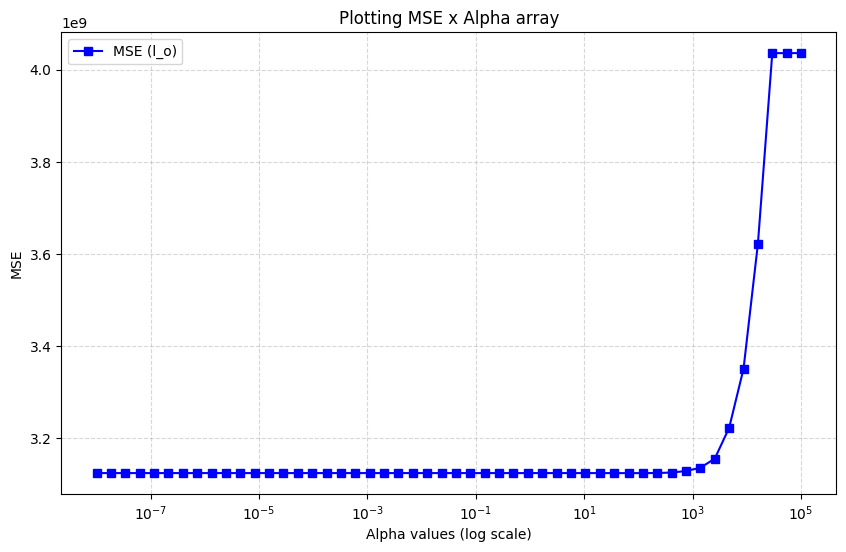

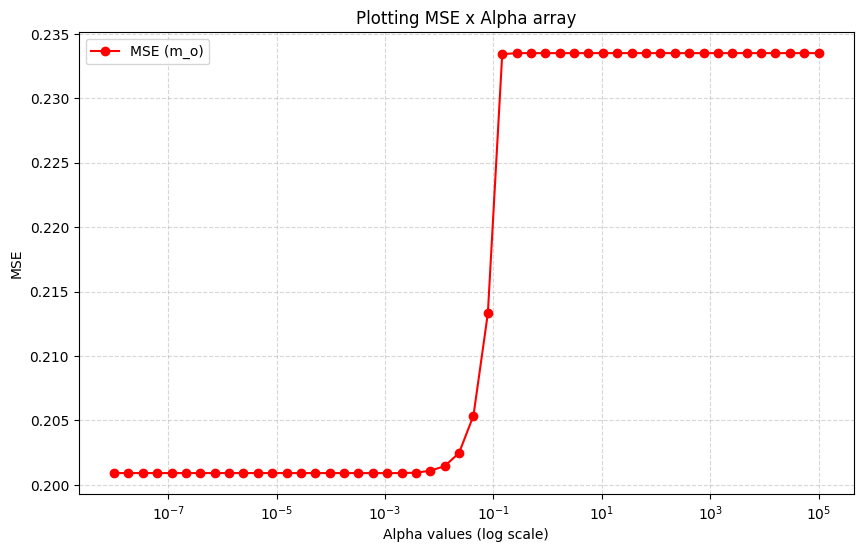

In [ ]:
# Plotting of tuning parameters (alpha) vs MSE for both m_o and l_o models
plt.figure(figsize=(10, 6))
plt.title("Plotting MSE l_o")
plt.xlabel("Alpha values (log scale)")
plt.ylabel("MSE")

plt.xscale('log') 

plt.plot(alpha_grid['alpha'], alpha_MSE_l_o_estimates, color="blue", marker="s", label="MSE (l_o)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


plt.figure(figsize=(10, 6))
plt.title("Plotting MSE m_o")
plt.xlabel("Alpha values (log scale)")
plt.ylabel("MSE")

plt.xscale('log') 

plt.plot(alpha_grid['alpha'], alpha_MSE_m_o_estimates, color="red", marker="o", label="MSE (m_o)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()




In [35]:

#Best choice of the tuning parameter(alpha) for m_o and l_o based on minimum MSE

df = pd.DataFrame({
    'alpha': alpha_grid['alpha'],
    'MSE_m_o': alpha_MSE_m_o_estimates,
    'MSE_l_o': alpha_MSE_l_o_estimates
})

print(df[df['MSE_m_o'] == min(alpha_MSE_m_o_estimates)])
print(df[df['MSE_l_o'] == min(alpha_MSE_l_o_estimates)])


NameError: name 'alpha_grid' is not defined

In [ ]:
#2 Fold Cross-validation with Lasso Regression

from sklearn.linear_model import Lasso
iterations = 1000
alpha_m=0.001099
alpha_l=65.512856 

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

theta_k_estimates = []
n_samples = len(data)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):
    
    kf = KFold(n_splits=2, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
        
        #Lasso_m_o
        Lasso_m_o = Lasso(alpha=alpha_m, random_state=i)
        Lasso_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - Lasso_m_o.predict(X_test)
        
        #Lasso_l_o
        Lasso_l_o = Lasso(alpha=alpha_l, random_state=i)
        Lasso_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - Lasso_l_o.predict(X_test)
             
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data['e401']) 
    theta_k_estimates.append(theta_k)

theta_ls2 = np.average(theta_k_estimates)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 2 fold cross-validation and Lasso Regression is: {theta_ls2}")

Finished 1000 iterations. Thank you for waiting!
The DML estimate with 5 fold cross-validation and Lasso Regression is: 5868.700822342094


In [ ]:
#5 Fold Cross-validation with Lasso Regression

from sklearn.linear_model import Lasso
iterations = 1000 
alpha_m=0.001099
alpha_l=65.512856 

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

theta_k_estimates = []
n_samples = len(data)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):
    
    kf = KFold(n_splits=5, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
        
        #Lasso_m_o
        Lasso_m_o = Lasso(alpha=alpha_m, random_state=i)
        Lasso_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - Lasso_m_o.predict(X_test)
        
        #Lasso_l_o
        Lasso_l_o = Lasso(alpha=alpha_l, random_state=i)
        Lasso_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - Lasso_l_o.predict(X_test)
             
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data['e401']) 
    theta_k_estimates.append(theta_k)

theta_ls5 = np.average(theta_k_estimates)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 5 fold cross-validation and Lasso Regression is: {theta_ls5}")

Finished 1000 iterations. Thank you for waiting!
The DML estimate with 5 fold cross-validation and Lasso Regression is: 5871.941872035096


In [ ]:
#10 Fold Cross-validation with Lasso Regression

from sklearn.linear_model import Lasso
iterations = 1000 
alpha_m=0.001099
alpha_l=65.512856 

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

theta_k_estimates = []
n_samples = len(data)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):
    
    kf = KFold(n_splits=10, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        # 2. Changed dots to underscores for variable names
        net_tfa_train, net_tfa_test = data['net_tfa'].iloc[train_idx], data['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data['e401'].iloc[train_idx], data['e401'].iloc[test_idx]
        
        #Lasso_m_o
        Lasso_m_o = Lasso(alpha=alpha_m, random_state=i)
        Lasso_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - Lasso_m_o.predict(X_test)
        
        #Lasso_l_o
        Lasso_l_o = Lasso(alpha=alpha_l, random_state=i)
        Lasso_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - Lasso_l_o.predict(X_test)
             
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data['e401']) 
    theta_k_estimates.append(theta_k)

theta_ls10 = np.average(theta_k_estimates)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 10 fold cross-validation and Lasso Regression is: {theta_ls10}")

Finished 1000 iterations. Thank you for waiting!
The DML estimate with 10 fold cross-validation and Lasso Regression is: 5874.39348627075


The result obtained are consisten with the paper ones, so the methodology has been applied correctly 
END or FINE(in Italian).


Now we look for the median and the mean of everyone of our variable in other to find one that is not skewed and then we divide the data base on that variable in order to have roughly 50% of the observation.

In [4]:
def get_mean_median_table(df):

    # 1. Select only numeric columns to avoid errors when calculating stats on text data
    numeric_df = df.select_dtypes(include='number')
    
    # 2. Calculate both 'mean' and 'median' using the aggregate function (.agg)
    stats_table = numeric_df.agg(['mean', 'median'])
    
    # 3. Transpose the table (.T) so that features are on the rows and stats are on the columns.
    return stats_table.T

result = get_mean_median_table(X)

print("--- Mean and Median Table ---")
print(result)

--- Mean and Median Table ---
                 mean   median
age         41.060212     40.0
inc      37200.621094  31476.0
educ        13.206253     12.0
fsize        2.865860      3.0
marr         0.604841      1.0
twoearn      0.380837      0.0
pira         0.242158      0.0
hown         0.635199      1.0
db           0.271004      0.0


In [ ]:
data_age_40 = data[data['age'] <= 40]
X_age_40 = X[X['age'] <= 40]
print(data_age_40.describe())
print(X_age_40.describe())

               nifa       net_tfa            tw          age            inc  \
count  5.183000e+03  5.183000e+03  5.183000e+03  5183.000000    5183.000000   
mean   8.177042e+03  8.736228e+03  3.559889e+04    32.778121   34716.269531   
std    4.006064e+04  4.631471e+04  7.331672e+04     4.452087   22477.130859   
min    0.000000e+00 -4.090000e+05 -2.997010e+05    25.000000      -9.000000   
25%    1.080000e+02 -1.350000e+03  1.000000e+03    29.000000   18597.000000   
50%    1.099000e+03  3.000000e+02  1.075000e+04    33.000000   29739.000000   
75%    5.121000e+03  7.360500e+03  4.238450e+04    37.000000   45067.500000   
max    1.303947e+06  1.317947e+06  1.375947e+06    40.000000  191715.000000   

             fsize         educ           db         marr      twoearn  \
count  5183.000000  5183.000000  5183.000000  5183.000000  5183.000000   
mean      2.901216    13.458615     0.231140     0.591549     0.391665   
std       1.572353     2.663810     0.421603     0.491595     0.48

In [11]:
data_age_41 = data[data['age'] > 40]
X_age_41 = X[X['age'] > 40]
print(data_age_41.describe())
print(X_age_41.describe())

               nifa       net_tfa            tw          age            inc  \
count  4.732000e+03  4.732000e+03  4.732000e+03  4732.000000    4732.000000   
mean   2.022842e+04  2.825467e+04  9.472421e+04    50.131657   39921.753906   
std    6.695761e+04  7.685702e+04  1.354643e+05     6.713841   26807.060547   
min    0.000000e+00 -5.023020e+05 -5.023020e+05    41.000000   -2652.000000   
25%    3.990000e+02  0.000000e+00  1.280000e+04    44.000000   20642.250000   
50%    2.800000e+03  5.000000e+03  5.338750e+04    49.000000   33711.000000   
75%    1.500000e+04  3.264800e+04  1.279562e+05    55.000000   52376.250000   
max    1.430298e+06  1.536798e+06  2.029910e+06    64.000000  242124.000000   

             fsize         educ           db         marr      twoearn  \
count  4732.000000  4732.000000  4732.000000  4732.000000  4732.000000   
mean      2.827134    12.929839     0.314666     0.619400     0.368977   
std       1.500694     2.938124     0.464432     0.485586     0.48

In [ ]:

#I decide to divide for age≤40.
X_age_40 = X[X['age'] <= 40]
data_age_40 = data[data['age'] <= 40]


iterations = 80 
theta_k_estimates_40 = []
n_samples = len(data_age_40)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):

    kf = KFold(n_splits=10, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data_age_40):
        X_train, X_test = X_age_40.iloc[train_idx], X_age_40.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data_age_40['net_tfa'].iloc[train_idx], data_age_40['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data_age_40['e401'].iloc[train_idx], data_age_40['e401'].iloc[test_idx]
        
        rf_m_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        
        rf_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - rf_m_o.predict(X_test)
         
        rf_l_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - rf_l_o.predict(X_test)
         
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data_age_40['e401']) 
    theta_k_estimates_40.append(theta_k)


theta_rf_age_40 = np.average(theta_k_estimates_40)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 10 fold cross-validation and Random Forest, for the observation with age ≤ 40 is: {theta_rf_age_40}")





Finished 80 iterations. Thank you for waiting!
The DML estimate with 10 fold cross-validation and Random Forest, for the observation with age ≤ 40 is: 6572.473472792393


In [27]:
print(data_age_41.columns.tolist())

['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']


In [ ]:
##...and age>40.
X_age_41 = X[X['age'] > 40]
data_age_41 = data[data['age'] > 40]


iterations = 80 
theta_k_estimates_41 = []
n_samples = len(data_age_41)
V_hat_cf = np.zeros(n_samples) 
U_hat_cf = np.zeros(n_samples)

np.random.seed(67)

for i in range(iterations):

    kf = KFold(n_splits=10, shuffle=True, random_state=i)

    for train_idx, test_idx in kf.split(data_age_41):
        X_train, X_test = X_age_41.iloc[train_idx], X_age_41.iloc[test_idx]
        
        net_tfa_train, net_tfa_test = data_age_41['net_tfa'].iloc[train_idx], data_age_41['net_tfa'].iloc[test_idx]
        e401_train, e401_test = data_age_41['e401'].iloc[train_idx], data_age_41['e401'].iloc[test_idx]
        
        rf_m_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        
        rf_m_o.fit(X_train, e401_train)
        V_hat_cf[test_idx] = e401_test - rf_m_o.predict(X_test)
         
        rf_l_o = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=i)
        rf_l_o.fit(X_train, net_tfa_train)
        U_hat_cf[test_idx] = net_tfa_test - rf_l_o.predict(X_test)
         
    theta_k = np.mean(V_hat_cf * U_hat_cf) / np.mean(V_hat_cf * data_age_41['e401']) 
    theta_k_estimates_41.append(theta_k)


theta_rf_age_41 = np.average(theta_k_estimates_41)

print(f"Finished {iterations} iterations. Thank you for waiting!\nThe DML estimate with 10 fold cross-validation and Random Forest, for the observation with age > 40 is: {theta_rf_age_41}")






Finished 80 iterations. Thank you for waiting!
The DML estimate with 10 fold cross-validation and Random Forest, for the observation with age > 40 is: 13028.80322988264


In [36]:
#Let's compare the two GATE estimates obtained, in this case represented by 
# the estimates of theta for the group with age ≤ 40 and the group with age > 40.
theta_young= theta_rf_age_40 
theta_old= theta_rf_age_41
print(f"GATE_young= {theta_young}")
print(f"GATE_old= {theta_old}")

e401_young = data_age_40['e401']
e401_old = data_age_41['e401']

size_young = float(len(data_age_40))
size_old = float(len(data_age_41))
p_e401_young= sum(e401_young)/size_young
p_e401_old= sum(e401_old)/size_old
print(f"p_e401_young= {p_e401_young}")
print(f"p_e401_old= {p_e401_old}")

var_young = p_e401_young * (1 - p_e401_young)
var_old = p_e401_old * (1 - p_e401_old)
print(f"Variance_young= {var_young}")
print(f"Variance_old= {var_old}")

weight_young= (var_young*size_young)/(var_young*size_young + var_old*size_old)
weight_old= (var_old*size_old)/(var_young*size_young + var_old*size_old)

print(f"Weight_young= {weight_young}")
print(f"Weight_old= {weight_old}")


first_term = theta_rf_age_40*weight_young
second_term = theta_rf_age_41*weight_old
theta_rf_final = first_term + second_term

print(f"Final estimate= {theta_rf_final}")


GATE_young= 6572.473472792393
GATE_old= 13028.80322988264
p_e401_young= 0.3492185992668339
p_e401_old= 0.3956043956043956
Variance_young= 0.22726496919294437
Variance_old= 0.23910155778287648
Weight_young= 0.510064716626204
Weight_old= 0.48993528337379594
Final estimate= 9735.657221887073


In [37]:
theta_rf10=9262.516846528491
print(f"Final estimate= {theta_rf_final} is so the final estimate of the effect of 401(k) eligibility on net financial assets, taking into account the heterogeneity in treatment effects across age groups (age ≤ 40 and age > 40). \nIt is different from the estimate obtained on the whole sample, which was {theta_rf10}.", end="", flush=True)

Final estimate= 9735.657221887073 is so the final estimate of the effect of 401(k) eligibility on net financial assets, taking into account the heterogeneity in treatment effects across age groups (age ≤ 40 and age > 40). 
It is different from the estimate obtained on the whole sample, which was 9262.516846528491.